In [2]:
import pandas as pd

In [3]:
from pathlib import Path
DATA_PATH = Path("/Users/vadik/brEcommerce")
tables = {
    'customers': 'olist_customers_dataset.csv', # клиенты
    'orders': 'olist_orders_dataset.csv', # заказы
    'items': 'olist_order_items_dataset.csv', # товары в заказах
    'payments': 'olist_order_payments_dataset.csv', # оплаты по заказам
    'reviews': 'olist_order_reviews_dataset.csv', # отзывы по заказам
    'products': 'olist_products_dataset.csv', # перечень товаров
    'sellers': 'olist_sellers_dataset.csv', # продавцы
    'geo': 'olist_geolocation_dataset.csv', # геолокации по зип-кодам
    'categories': 'product_category_name_translation.csv', # категории товаров
    'category_translations': 'product_category_name_translation.csv' # переводы названий категорий
}

data = {}
for name, filename in tables.items():
    filepath = DATA_PATH / filename
    if filepath.exists():
        data[name] = pd.read_csv(filepath)
        print(f"✅ {name}: {data[name].shape}")
    else:
        print(f"❌ Не найдено: {filename}")

✅ customers: (99441, 5)
✅ orders: (99441, 8)
✅ items: (112650, 7)
✅ payments: (103886, 5)
✅ reviews: (99224, 7)
✅ products: (32951, 9)
✅ sellers: (3095, 4)
✅ geo: (1000163, 5)
✅ categories: (71, 2)
✅ category_translations: (71, 2)


In [6]:
orders_v_reviews = pd.merge(data['orders'], data['reviews'], on='order_id', how='left')

In [8]:
orders_v_reviews['review_score'].isnull().sum()

np.int64(768)

In [50]:
orders_v_reviews = orders_v_reviews[ (orders_v_reviews['review_score'] != 0) &
    (orders_v_reviews['review_score'].notna())].copy()

In [51]:
orders_v_reviews = orders_v_reviews.drop_duplicates(subset=['order_id'], keep='first')

In [19]:
done_orders = orders_v_reviews[orders_v_reviews['order_status'] == 'delivered'].copy()

In [53]:
done_orders['order_delivered_customer_date'] = pd.to_datetime(done_orders['order_delivered_customer_date'])

In [21]:
done_orders['order_purchase_timestamp'] = pd.to_datetime(done_orders['order_purchase_timestamp'])

In [22]:
done_orders['deliv_delta'] = done_orders['order_delivered_customer_date'] - done_orders['order_purchase_timestamp']

In [37]:
done_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99991
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       96478 non-null  object         
 1   customer_id                    96478 non-null  object         
 2   order_status                   96478 non-null  object         
 3   order_purchase_timestamp       96478 non-null  datetime64[ns] 
 4   order_approved_at              96464 non-null  object         
 5   order_delivered_carrier_date   96476 non-null  object         
 6   order_delivered_customer_date  96470 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  96478 non-null  object         
 8   review_id                      95832 non-null  object         
 9   review_score                   95832 non-null  Int64          
 10  review_comment_title           11191 non-null  object         
 11  review_

In [29]:
done_orders['deliv_delta_days'] = done_orders['deliv_delta'].dt.days

In [35]:
done_orders['deliv_delta_days'] = done_orders['deliv_delta_days'].astype('Int64')
done_orders['review_score'] = done_orders['review_score'].astype('Int64')

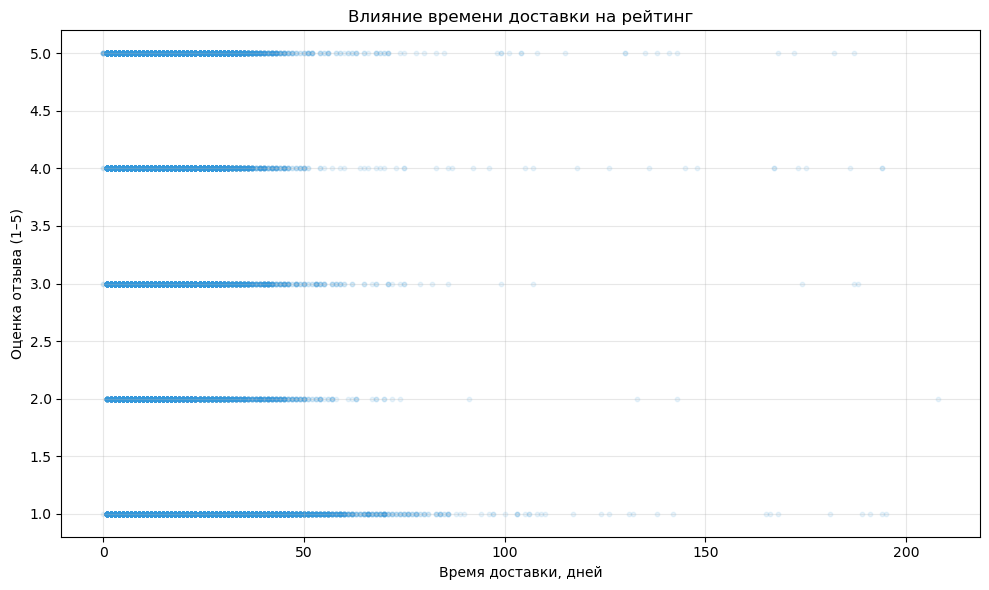

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(
    done_orders['deliv_delta_days'],
    done_orders['review_score'],
    alpha=0.1,  # прозрачность, чтобы видеть плотность
    s=10,       # маленький размер точек
    color='#3498db'
)

plt.xlabel('Время доставки, дней')
plt.ylabel('Оценка отзыва (1–5)')
plt.title('Влияние времени доставки на рейтинг')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/charts/delivery_scatter_raw.png', dpi=150)
plt.show()

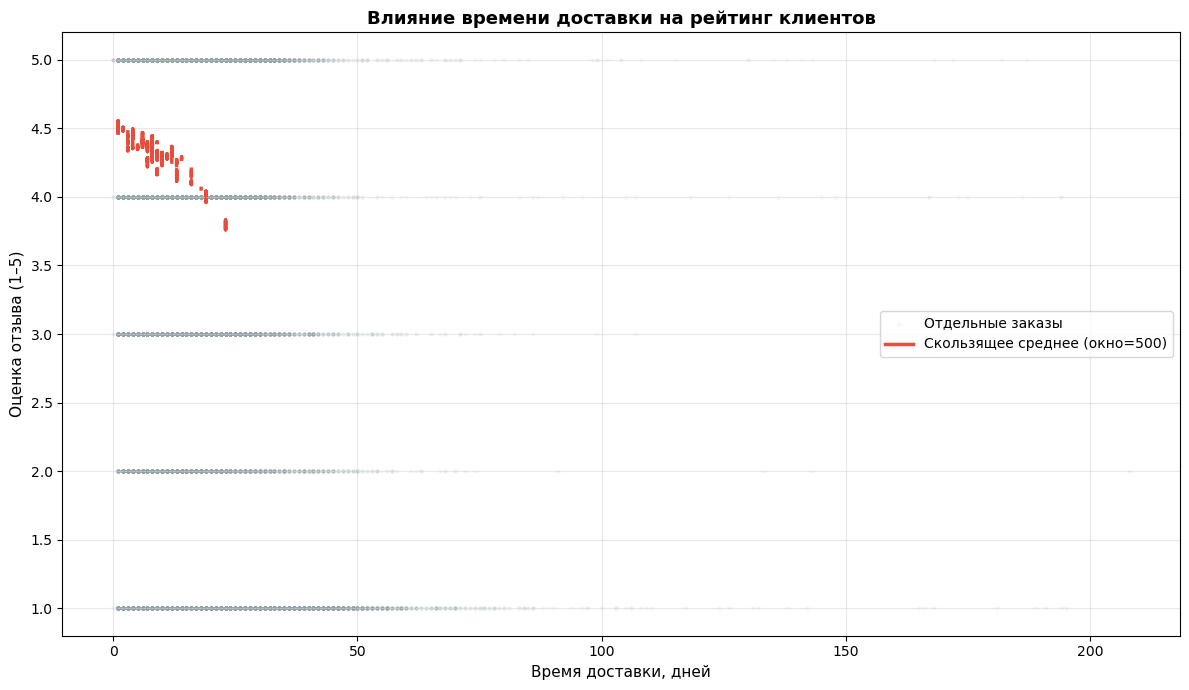

In [57]:
import numpy as np

# Сортируем для линии тренда
sorted_df = done_orders.sort_values('deliv_delta_days').copy()

# Считаем скользящее среднее рейтинга (окно 500 заказов)
sorted_df['rating_smooth'] = sorted_df['review_score'].rolling(window=500, center=True).mean()

plt.figure(figsize=(12, 7))

# Scatter (полупрозрачный)
plt.scatter(
    done_orders['deliv_delta_days'],
    done_orders['review_score'],
    alpha=0.05,
    s=5,
    color='#95a5a6',
    label='Отдельные заказы'
)

# Линия тренда
plt.plot(
    sorted_df['deliv_delta_days'],
    sorted_df['rating_smooth'],
    color='#e74c3c',
    linewidth=2.5,
    label='Скользящее среднее (окно=500)'
)

# Горизонтальные линии-ориентиры
for rating in [1, 2, 3, 4, 5]:
    plt.axhline(y=rating, color='#ecf0f1', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel('Время доставки, дней', fontsize=11)
plt.ylabel('Оценка отзыва (1–5)', fontsize=11)
plt.title('Влияние времени доставки на рейтинг клиентов', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/charts/delivery_vs_rating_rolling.png', dpi=150)
plt.show()

In [58]:
orders_75 = done_orders[done_orders['deliv_delta_days'] <= 75]

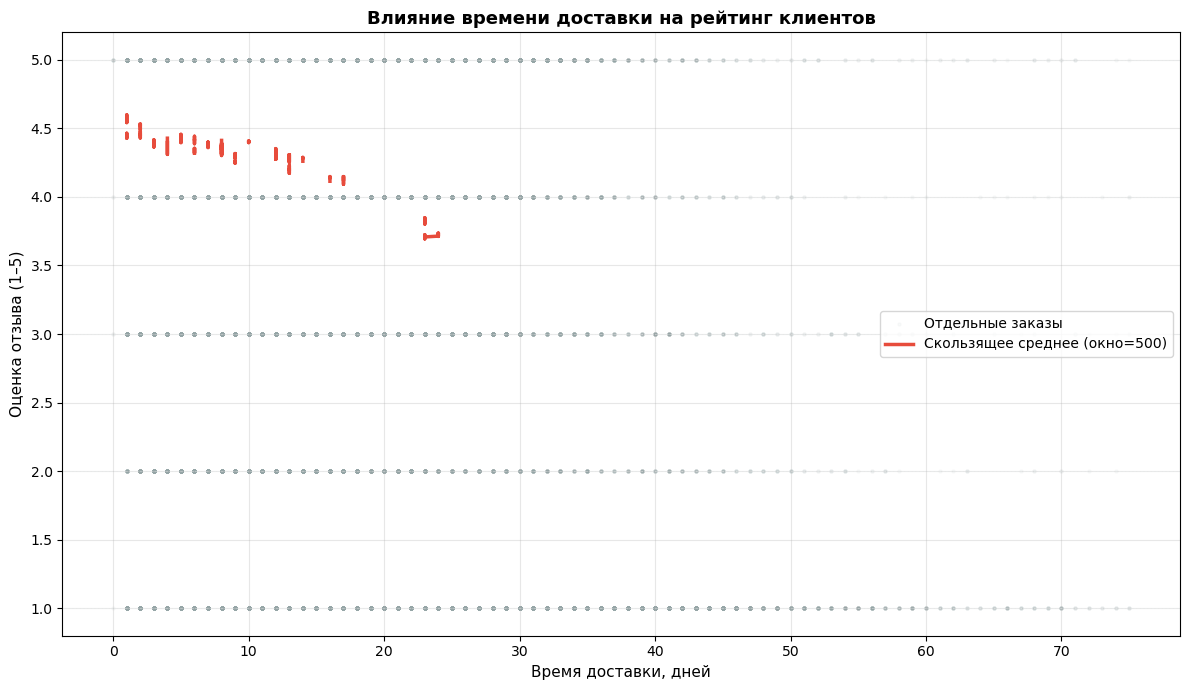

In [59]:
# Сортируем для линии тренда
sorted_df = orders_75.sort_values('deliv_delta_days').copy()

# Считаем скользящее среднее рейтинга (окно 500 заказов)
sorted_df['rating_smooth'] = sorted_df['review_score'].rolling(window=500, center=True).mean()

plt.figure(figsize=(12, 7))

# Scatter (полупрозрачный)
plt.scatter(
    orders_75['deliv_delta_days'],
    orders_75['review_score'],
    alpha=0.05,
    s=5,
    color='#95a5a6',
    label='Отдельные заказы'
)

# Линия тренда
plt.plot(
    sorted_df['deliv_delta_days'],
    sorted_df['rating_smooth'],
    color='#e74c3c',
    linewidth=2.5,
    label='Скользящее среднее (окно=500)'
)

# Горизонтальные линии-ориентиры
for rating in [1, 2, 3, 4, 5]:
    plt.axhline(y=rating, color='#ecf0f1', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel('Время доставки, дней', fontsize=11)
plt.ylabel('Оценка отзыва (1–5)', fontsize=11)
plt.title('Влияние времени доставки на рейтинг клиентов', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/charts/delivery_vs_rating_rolling_zoom.png', dpi=150)
plt.show()

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Создаём бины на основе бизнес-логики
bins = [0, 3, 7, 12, 20, 40, 100]
labels = ['0-3 дня', '4-7 дней', '8-12 дней', '13-20 дней', '21-40 дней', '40+ дней']

# 2. Применяем биннинг к deliv_delta_days
done_orders['delivery_bin'] = pd.cut(
    done_orders['deliv_delta_days'],
    bins=bins,
    labels=labels,
    right=True,  # интервалы (0,3], (3,7], ...
    include_lowest=True  # включить 0 в первый бин
)

# 3. Агрегируем данные по бинам
bin_stats = done_orders.groupby('delivery_bin', observed=True).agg(
    avg_rating=('review_score', 'mean'),
    rating_std=('review_score', 'std'),  # разброс оценок
    order_count=('order_id', 'count'),
    pct_of_total=('order_id', lambda x: len(x) / len(done_orders) * 100)
).round(2)

# 4. Выводим таблицу для анализа
print("📊 Статистика по интервалам доставки:")
print(bin_stats.to_string())

📊 Статистика по интервалам доставки:
              avg_rating  rating_std  order_count  pct_of_total
delivery_bin                                                   
0-3 дня             4.46        1.04         8602          8.92
4-7 дней            4.39        1.08        25094         26.01
8-12 дней           4.31        1.14        28186         29.21
13-20 дней          4.16        1.23        22089         22.90
21-40 дней          3.31        1.62        10885         11.28
40+ дней            1.78        1.31         1551          1.61


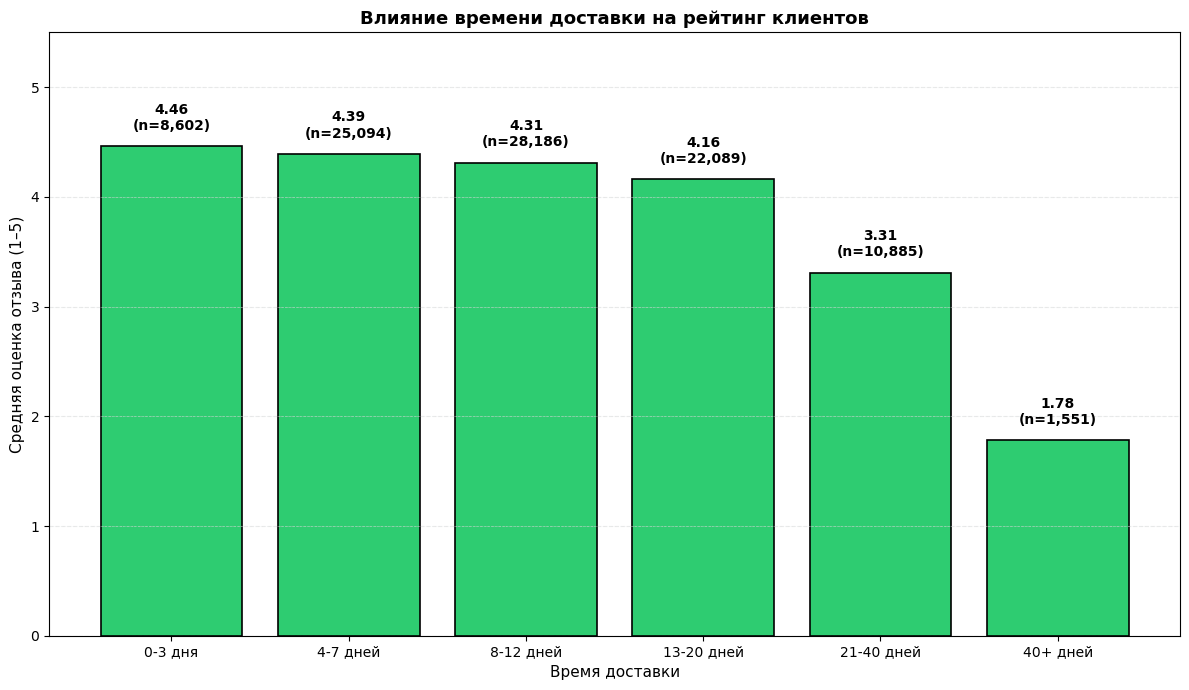

In [48]:
plt.figure(figsize=(12, 7))

# Столбцы: средний рейтинг
bars = plt.bar(
    bin_stats.index.astype(str),
    bin_stats['avg_rating'],
    color='#2ecc71',
    edgecolor='black',
    linewidth=1.2
)

# Добавляем подписи: рейтинг + количество заказов
for i, (label, row) in enumerate(bin_stats.iterrows()):
    plt.text(
        i, 
        row['avg_rating'] + 0.15, 
        f"{row['avg_rating']:.2f}\n(n={row['order_count']:,})", 
        ha='center', 
        fontsize=10,
        fontweight='bold'
    )

# Горизонтальные линии-ориентиры для рейтинга 1-5
for rating in [1, 2, 3, 4, 5]:
    plt.axhline(y=rating, color='#ecf0f1', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel('Время доставки', fontsize=11)
plt.ylabel('Средняя оценка отзыва (1–5)', fontsize=11)
plt.title('Влияние времени доставки на рейтинг клиентов', fontsize=13, fontweight='bold')
plt.ylim(0, 5.5)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('C:/Users/vadik/outputs/charts/delivery_binned_rating.png', dpi=150, bbox_inches='tight')
plt.show()